# 52 - 顔Embedding抽出とDuckDB保存

全378画像から顔を検出し、ArcFace 512次元 Embedding を抽出して DuckDB に保存する。
1画像に複数の顔がある場合、それぞれを個別のレコードとして保存する (1:N)。

## 入力
- `data/images.duckdb` (image_catalog テーブル)

## 出力
- `data/images.duckdb` (face_detections テーブル + HNSWインデックス)

In [1]:
import json
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from insightface.app import FaceAnalysis
from tqdm.notebook import tqdm

2026-02-14 16:14:45.608446128 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 設定

In [2]:
# DuckDBファイルのパス
DB_PATH = Path("../data/images.duckdb")

# InsightFace 設定
MODEL_NAME = "buffalo_l"
MODEL_FULL_NAME = "insightface/buffalo_l"  # DB保存用
DET_SIZE = (640, 640)
EMBEDDING_DIM = 512

# コミット間隔
COMMIT_INTERVAL = 50

## モデルの初期化

In [3]:
print("InsightFace モデルを読み込み中...")
app = FaceAnalysis(name=MODEL_NAME, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
app.prepare(ctx_id=0, det_size=DET_SIZE)
print(f"モデル: {MODEL_FULL_NAME}")
print(f"Embedding次元: {EMBEDDING_DIM}")

InsightFace モデルを読み込み中...
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/terapyon/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
モデル: insightface/buffalo_l
Embedding次元

## DuckDB テーブル作成

### スキーマ設計
- `face_id`: 検出された顔ごとのUUID (PK)
- `image_id`: 元画像のID (image_catalog.id へのFK)
- 1画像 → 複数の顔レコード (1:N の関係)
- `embedding FLOAT[512]`: ArcFace 512次元の正規化済みベクトル

In [4]:
conn = duckdb.connect(str(DB_PATH))

# VSS拡張を有効化
conn.execute("INSTALL vss; LOAD vss;")

# face_detections テーブル作成
conn.execute(f"""
    CREATE TABLE IF NOT EXISTS face_detections (
        face_id VARCHAR PRIMARY KEY,
        image_id VARCHAR NOT NULL,
        model_name VARCHAR NOT NULL,
        bbox_x1 FLOAT NOT NULL,
        bbox_y1 FLOAT NOT NULL,
        bbox_x2 FLOAT NOT NULL,
        bbox_y2 FLOAT NOT NULL,
        det_score FLOAT NOT NULL,
        landmark JSON,
        age INTEGER,
        gender VARCHAR,
        embedding FLOAT[{EMBEDDING_DIM}],
        person_label VARCHAR,
        cluster_id INTEGER,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

print("face_detections テーブル作成完了")

# 既存レコード数を確認
existing = conn.execute("""
    SELECT COUNT(*) FROM face_detections 
    WHERE model_name = ?
""", [MODEL_FULL_NAME]).fetchone()[0]
print(f"既存レコード数 ({MODEL_FULL_NAME}): {existing}")

face_detections テーブル作成完了
既存レコード数 (insightface/buffalo_l): 0


## 処理対象の確認

In [5]:
# 処理済み画像IDを取得
processed_ids = set(
    row[0] for row in conn.execute("""
        SELECT DISTINCT image_id FROM face_detections
        WHERE model_name = ?
    """, [MODEL_FULL_NAME]).fetchall()
)

# 全画像を取得
all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

# 未処理画像
pending_images = all_images[~all_images["id"].isin(processed_ids)]

print(f"総画像数: {len(all_images)}")
print(f"処理済み: {len(processed_ids)}")
print(f"未処理: {len(pending_images)}")

総画像数: 378
処理済み: 0
未処理: 378


## 顔検出 + Embedding 抽出 + DB保存

In [6]:
total_faces = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(pending_images.iterrows(), total=len(pending_images), desc="顔検出+Embedding")):
    try:
        img = cv2.imread(row["file_path"])
        if img is None:
            errors.append((row["id"], "画像読み込み失敗"))
            continue

        faces = app.get(img)
        total_images += 1

        for face in faces:
            face_id = str(uuid.uuid4())
            bbox = face.bbox.astype(float)
            gender = "M" if face.gender == 1 else "F"
            landmark = json.dumps(face.kps.tolist()) if face.kps is not None else None
            embedding = face.normed_embedding.tolist()

            conn.execute("""
                INSERT INTO face_detections 
                (face_id, image_id, model_name, bbox_x1, bbox_y1, bbox_x2, bbox_y2,
                 det_score, landmark, age, gender, embedding)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            """, [
                face_id, row["id"], MODEL_FULL_NAME,
                bbox[0], bbox[1], bbox[2], bbox[3],
                float(face.det_score), landmark,
                int(face.age), gender, embedding
            ])
            total_faces += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    # 定期的にコミット
    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

# 最終コミット
conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  検出顔数: {total_faces}")
print(f"  エラー数: {len(errors)}")
print(f"  処理時間: {elapsed:.1f} 秒 ({elapsed/max(total_images,1):.2f} 秒/枚)")

if errors:
    print(f"\nエラー一覧:")
    for id_, err in errors[:10]:
        print(f"  {id_}: {err}")

顔検出+Embedding:   0%|          | 0/378 [00:00<?, ?it/s]

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



処理完了:
  処理画像数: 378
  検出顔数: 691
  エラー数: 0
  処理時間: 67.1 秒 (0.18 秒/枚)


## HNSW インデックス作成

In [7]:
# 永続化されたDBでHNSWインデックスを使うための設定
conn.execute("SET hnsw_enable_experimental_persistence = true")

# 既存のインデックスを削除（あれば）
try:
    conn.execute("DROP INDEX IF EXISTS face_embedding_idx")
except Exception:
    pass

# HNSWインデックス作成（コサイン類似度）
print("HNSW インデックスを作成中...")
conn.execute("""
    CREATE INDEX face_embedding_idx
    ON face_detections
    USING HNSW (embedding)
    WITH (metric = 'cosine')
""")
print("HNSW インデックス作成完了")

HNSW インデックスを作成中...


HNSW インデックス作成完了


## 保存結果の確認

In [8]:
# 総レコード数
total = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
print(f"face_detections 総レコード数: {total}")

# カテゴリ別統計
cat_stats = conn.execute("""
    SELECT 
        c.category,
        COUNT(DISTINCT c.id) as image_count,
        COUNT(f.face_id) as face_count,
        ROUND(AVG(f.det_score), 3) as avg_score,
        ROUND(AVG(f.age), 1) as avg_age
    FROM image_catalog c
    LEFT JOIN face_detections f ON c.id = f.image_id
    GROUP BY c.category
    ORDER BY face_count DESC
""").fetchdf()

cat_stats["faces_per_image"] = (cat_stats["face_count"] / cat_stats["image_count"]).round(1)

print("\nカテゴリ別統計:")
display(cat_stats)

face_detections 総レコード数: 691

カテゴリ別統計:


,category,image_count,face_count,avg_score,avg_age,faces_per_image
0,EuroPython2025,129,345,0.740,42.2,2.7
1,PyConJP2025,77,294,0.735,48.2,3.8
2,PyConJP2025-PreCampHiroshima,57,37,0.691,38.4,0.6
3,terada,10,10,0.870,54.2,1.0
4,TokyoNight202505,49,4,0.810,63.3,0.1
5,KashiwaVillagePark2026,56,1,0.505,31.0,0.0


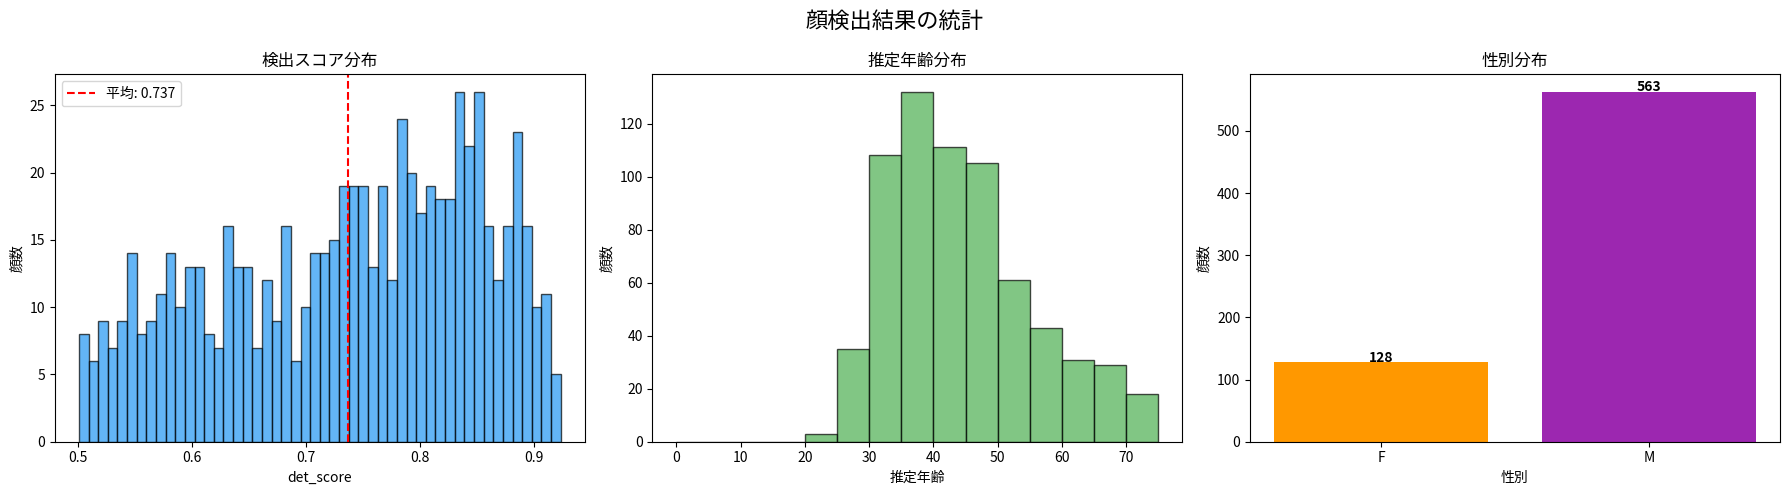

In [9]:
# 検出スコア分布
scores = conn.execute("""
    SELECT det_score FROM face_detections
""").fetchdf()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 検出スコア分布
axes[0].hist(scores["det_score"], bins=50, edgecolor="black", alpha=0.7, color="#2196F3")
axes[0].set_title("検出スコア分布")
axes[0].set_xlabel("det_score")
axes[0].set_ylabel("顔数")
axes[0].axvline(scores["det_score"].mean(), color="red", linestyle="--",
                label=f"平均: {scores['det_score'].mean():.3f}")
axes[0].legend()

# 2. 年齢分布
ages = conn.execute("SELECT age FROM face_detections WHERE age IS NOT NULL").fetchdf()
axes[1].hist(ages["age"], bins=range(0, 80, 5), edgecolor="black", alpha=0.7, color="#4CAF50")
axes[1].set_title("推定年齢分布")
axes[1].set_xlabel("推定年齢")
axes[1].set_ylabel("顔数")

# 3. 性別分布
gender_counts = conn.execute("""
    SELECT gender, COUNT(*) as count
    FROM face_detections
    GROUP BY gender
""").fetchdf()
axes[2].bar(gender_counts["gender"], gender_counts["count"], color=["#FF9800", "#9C27B0"])
axes[2].set_title("性別分布")
axes[2].set_xlabel("性別")
axes[2].set_ylabel("顔数")
for i, row in gender_counts.iterrows():
    axes[2].text(i, row["count"] + 1, str(row["count"]), ha="center", fontweight="bold")

plt.suptitle("顔検出結果の統計", fontsize=16)
plt.tight_layout()
plt.show()

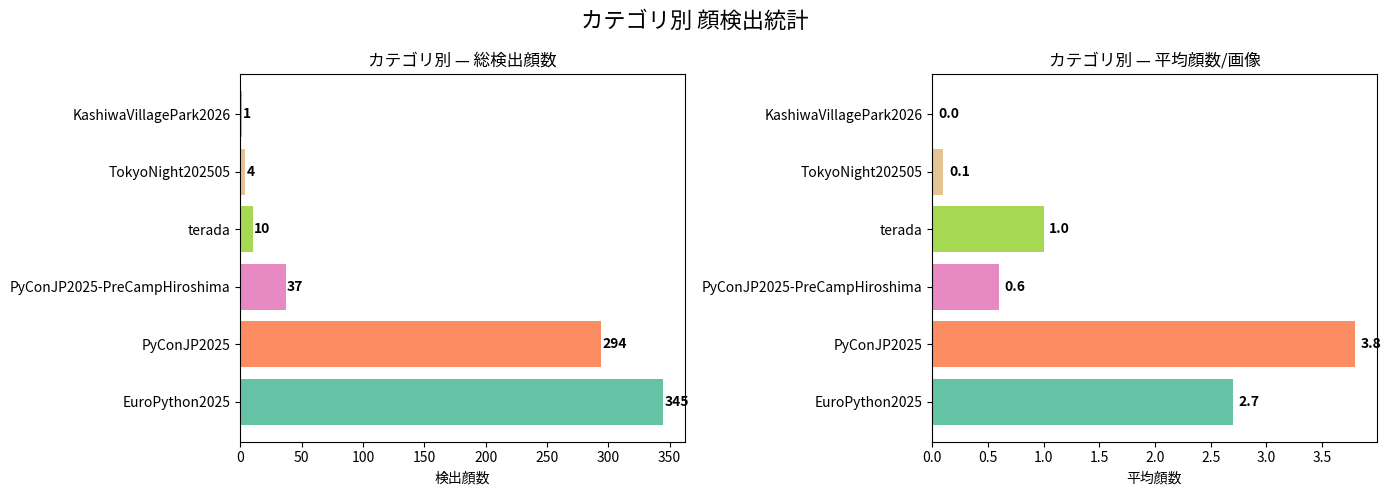

In [10]:
# カテゴリ別の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(cat_stats)))

# 顔数バーチャート
bars = ax1.barh(cat_stats["category"], cat_stats["face_count"], color=colors)
ax1.set_title("カテゴリ別 — 総検出顔数")
ax1.set_xlabel("検出顔数")
for bar, val in zip(bars, cat_stats["face_count"]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(val)), va="center", fontweight="bold")

# 平均顔数/画像
bars = ax2.barh(cat_stats["category"], cat_stats["faces_per_image"], color=colors)
ax2.set_title("カテゴリ別 — 平均顔数/画像")
ax2.set_xlabel("平均顔数")
for bar, val in zip(bars, cat_stats["faces_per_image"]):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", fontweight="bold")

plt.suptitle("カテゴリ別 顔検出統計", fontsize=16)
plt.tight_layout()
plt.show()

## 検索テスト

HNSW インデックスを使って、terada の顔で類似検索を試す。

In [11]:
# terada の最初の顔 Embedding を取得
terada_face = conn.execute("""
    SELECT f.face_id, f.embedding, c.file_name
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY f.det_score DESC
    LIMIT 1
""").fetchone()

print(f"クエリ顔: {terada_face[2]} (face_id: {terada_face[0][:8]}...)")

# 類似検索
query_embedding = terada_face[1]
results = conn.execute(f"""
    SELECT 
        f.face_id,
        f.image_id,
        c.file_name,
        c.category,
        f.det_score,
        f.age,
        f.gender,
        array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    ORDER BY distance
    LIMIT 10
""", [[float(x) for x in query_embedding]]).fetchdf()

results["similarity"] = 1.0 - results["distance"]

print("\n類似検索 Top 10:")
display(results[["file_name", "category", "similarity", "age", "gender", "det_score"]])

クエリ顔: terada-202205-pyconjp-4-3-900.jpg (face_id: 4b6041ef...)

類似検索 Top 10:


,file_name,category,similarity,age,gender,det_score
0,terada-202205-pyconjp-4-3-900.jpg,terada,1.000000,57,M,0.912513
1,terada-2020-square-500.jpg,terada,0.800924,41,M,0.887685
2,2025-07-16 18.40.31.jpg,EuroPython2025,0.792903,56,M,0.914181
3,202203証明写真オリジナル.jpg,terada,0.781339,49,M,0.900003
4,terada-pao-2025.jpg,terada,0.769791,60,M,0.896674
5,2025-07-16 00.37.53.jpg,EuroPython2025,0.769677,54,M,0.912421
6,TeradaPyConJP.jpg,terada,0.746388,49,M,0.873109
7,2025-09-27 15.23.34.jpg,PyConJP2025,0.743805,53,M,0.874188
8,2025-09-27 15.33.31.jpg,PyConJP2025,0.733281,60,M,0.899750
9,2025-07-18 00.31.47.jpg,EuroPython2025,0.725177,63,M,0.907745


## まとめ

### 実施内容
- 全378画像から顔を検出し、ArcFace 512次元 Embedding を抽出
- `face_detections` テーブルに保存（1画像 → 複数顔レコード）
- HNSW インデックスを構築し、コサイン類似度での高速検索を可能にした

### 次のステップ
- **Notebook 53**: terada をクエリとして、カンファレンス写真から同一人物を検索

In [12]:
conn.close()
print(f"完了: {DB_PATH.resolve()}")

完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb


## 補足: DB構造の解説

### CLIP/SigLIP の画像 Embedding との違い

これまでの実験 (Notebook 01-41) では、1枚の画像に対して **1つの Embedding ベクトル** を生成していた。

```
image_embeddings テーブル:
  画像A (id=xxx) → embedding FLOAT[768]  ← 画像全体で1ベクトル
  画像B (id=yyy) → embedding FLOAT[768]
```

顔認識では、1枚の画像に **複数の人物** が写っている場合がある。
そのため、検出された **顔ごとに個別の Embedding ベクトル** を生成し、それぞれを独立したレコードとして保存する。

### `face_detections` テーブルのスキーマ

```sql
CREATE TABLE face_detections (
    face_id VARCHAR PRIMARY KEY,       -- 顔ごとのUUID (1画像に複数あり得る)
    image_id VARCHAR NOT NULL,         -- image_catalog.id へのFK
    model_name VARCHAR NOT NULL,       -- 'insightface/buffalo_l'
    bbox_x1 FLOAT, bbox_y1 FLOAT,     -- バウンディングボックス (左上)
    bbox_x2 FLOAT, bbox_y2 FLOAT,     -- バウンディングボックス (右下)
    det_score FLOAT NOT NULL,          -- 検出信頼度
    landmark JSON,                     -- 5点ランドマーク
    age INTEGER,                       -- 推定年齢
    gender VARCHAR,                    -- 'M' / 'F'
    embedding FLOAT[512],              -- ArcFace 512次元ベクトル (L2正規化済み)
    person_label VARCHAR,              -- 手動ラベル (例: 'terada')
    cluster_id INTEGER,                -- クラスタリング結果
    created_at TIMESTAMP
)
```

### 1:N のリレーション

```
image_catalog (1枚の画像)
  │
  └── face_detections (N個の顔レコード)
       ├── face_id: uuid-aaa  (顔A, embedding[512], bbox, age=30, gender=M)
       ├── face_id: uuid-bbb  (顔B, embedding[512], bbox, age=45, gender=F)
       └── face_id: uuid-ccc  (顔C, embedding[512], bbox, age=25, gender=M)
```

- **PK**: `face_id` (UUID) — 画像単位ではなく、顔単位で一意
- **FK**: `image_id` → `image_catalog.id` で元画像と結合
- 1枚のカンファレンス写真から最大数十個の顔レコードが生成される

### HNSW インデックスによるベクトル検索

`embedding` カラムに HNSW インデックス (コサイン距離) を作成済み。
これにより、クエリ顔の Embedding に対して高速に類似顔を検索できる。

```sql
-- 例: terada の顔で類似検索
SELECT f.face_id, c.file_name,
       array_cosine_distance(f.embedding, query_vec) as distance
FROM face_detections f
JOIN image_catalog c ON f.image_id = c.id
ORDER BY distance
LIMIT 10
```

### データ規模 (本ノートブック実行時)

| 項目 | 値 |
|------|------|
| 入力画像数 | 378 |
| 検出された顔数 | 691 |
| 平均顔数/画像 | 約 1.8 |
| カンファレンス写真 (PyConJP2025) | 平均 3.8 顔/画像 |
| ポートレート (terada) | 1.0 顔/画像 |
| 風景写真 (KashiwaVillagePark2026) | ほぼ 0 顔/画像 |